
LOADING: Mixed-Baseline
  -> easy
  -> medium
  -> hard

LOADING: Water-Baseline
  -> easy
  -> medium
  -> hard

LOADING: Mixed-Residual
  -> easy
  -> medium
  -> hard

LOADING: Water-Residual
  -> easy
  -> medium
  -> hard


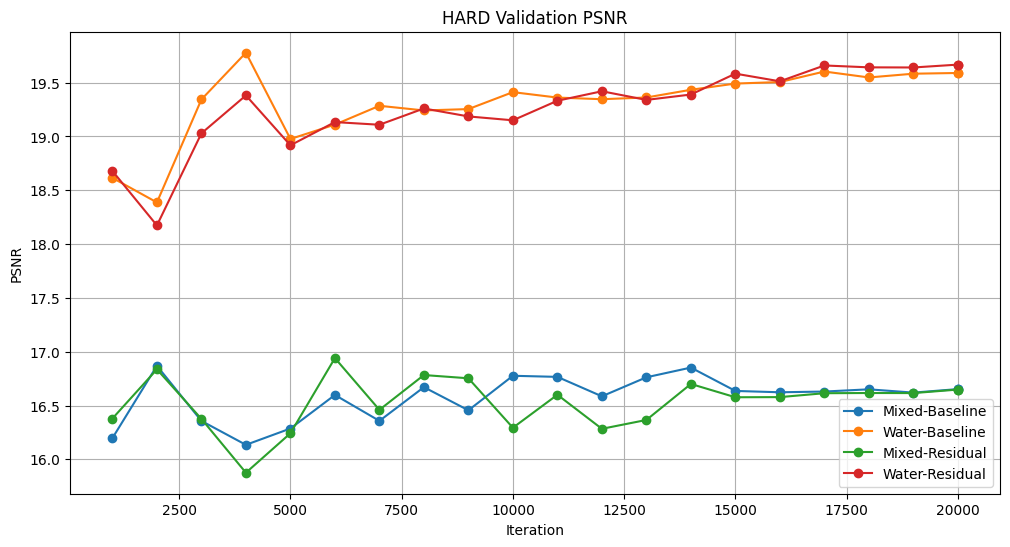

KeyError: 'val_iters'

<Figure size 1200x600 with 0 Axes>

In [6]:
import re
import matplotlib.pyplot as plt
from pathlib import Path

LOGS = {

    'Mixed-Baseline': {

        'easy':
        r'C:\DNN\deepLearning\NAFNet\experiments\NAFNet-mixed-easy-w16\train_NAFNet-mixed-easy-w16_20260604_094627.log',

        'medium':
        r'C:\DNN\deepLearning\NAFNet\experiments\NAFNet-mixed-medium-w16\train_NAFNet-mixed-medium-w16_20260604_160536.log',

        'hard':
        r'C:\DNN\deepLearning\NAFNet\experiments\NAFNet-mixed-hard-w16\train_NAFNet-mixed-hard-w16_20260604_125217.log'
    },

    'Water-Baseline': {

        'easy':
        r'C:\DNN\deepLearning\NAFNet\experiments\NAFNet-water-easy-w16\train_NAFNet-water-easy-w32_20260603_214052.log',

        'medium':
        r'C:\DNN\deepLearning\NAFNet\experiments\NAFNet-water-medium-w16\train_NAFNet-water-medium-w32_20260604_034234.log',

        'hard':
        r'C:\DNN\deepLearning\NAFNet\experiments\NAFNet-water-hard-w16\train_NAFNet-water-hard-w32_20260604_003953.log'
    },

    'Mixed-Residual': {

        'easy':
        r'C:\DNN\deepLearning\NAFNet\experiments\Residual-NAFNet-mixed-easy-w16\train_Residual-NAFNet-mixed-easy-w16_20260605_013439.log',

        'medium':
        r'C:\DNN\deepLearning\NAFNet\experiments\Residual-NAFNet-mixed-medium-w16\train_Residual-NAFNet-mixed-medium-w16_20260605_073054.log',

        'hard':
        r'C:\DNN\deepLearning\NAFNet\experiments\Residual-NAFNet-mixed-hard-w16\train_Residual-NAFNet-mixed-hard-w16_20260605_043047.log'
    },

    'Water-Residual': {

        'easy':
        r'C:\DNN\deepLearning\NAFNet\experiments\Residual-NAFNet-water-easy-w16\train_Residual-NAFNet-water-easy-w16_20260605_102444.log',

        'medium':
        r'C:\DNN\deepLearning\NAFNet\experiments\Residual-NAFNet-water-medium-w16\train_Residual-NAFNet-water-medium-w16_20260605_161813.log',

        'hard':
        r'C:\DNN\deepLearning\NAFNet\experiments\Residual-NAFNet-water-hard-w16\train_Residual-NAFNet-water-hard-w16_20260605_131723.log'
    }
}

# =========================================================
# REGEX
# =========================================================

train_pattern = re.compile(
    r'iter:\s*([\d,]+).*?l_pix:\s*(-?[0-9.eE+]+)'
)

val_pattern = re.compile(
    r'Validation.*?# psnr:\s*([0-9.]+)\s*# ssim:\s*([0-9.]+)'
)

iter_pattern = re.compile(
    r'iter:\s*([\d,]+)'
)

# =========================================================
# STORAGE
# =========================================================

results = {}

# =========================================================
# PARSE LOGS
# =========================================================
for experiment_name, difficulty_logs in LOGS.items():

    results[experiment_name] = {}

    print(f'\n{"="*70}')
    print(f'LOADING: {experiment_name}')
    print(f'{"="*70}')

    for difficulty, log_path in difficulty_logs.items():

        print(f'  -> {difficulty}')

        with open(
            log_path,
            'r',
            encoding='utf-8'
        ) as f:

            lines = f.readlines()

        train_iters = []
        train_losses = []

        val_iters = []
        val_psnr = []
        val_ssim = []

        current_iter = None

        for line in lines:

            iter_match = iter_pattern.search(line)

            if iter_match:

                current_iter = int(
                    iter_match.group(1).replace(',', '')
                )

            train_match = train_pattern.search(line)

            if train_match:

                iteration = int(
                    train_match.group(1).replace(',', '')
                )

                loss = float(
                    train_match.group(2)
                )

                train_iters.append(iteration)
                train_losses.append(loss)

            val_match = val_pattern.search(line)

            if val_match and current_iter is not None:

                psnr = float(
                    val_match.group(1)
                )

                ssim = float(
                    val_match.group(2)
                )

                val_iters.append(current_iter)
                val_psnr.append(psnr)
                val_ssim.append(ssim)

        results[experiment_name][difficulty] = {

            'train_iters': train_iters,
            'train_losses': train_losses,

            'val_iters': val_iters,
            'val_psnr': val_psnr,
            'val_ssim': val_ssim
        }



# =========================================================
# FIGURE 2 : VALIDATION PSNR
# =========================================================

difficulty = 'hard'

plt.figure(figsize=(12,6))

for experiment in results:

    plt.plot(
        results[experiment][difficulty]['val_iters'],
        results[experiment][difficulty]['val_psnr'],
        marker='o',
        label=experiment
    )

plt.title(f'{difficulty.upper()} Validation PSNR')
plt.xlabel('Iteration')
plt.ylabel('PSNR')

plt.grid(True)
plt.legend()

plt.show()

# =========================================================
# FIGURE 3 : VALIDATION SSIM
# =========================================================

difficulty = 'hard'

plt.figure(figsize=(12,6))

for difficulty in results:

    plt.plot(
        results[difficulty]['val_iters'],
        results[difficulty]['val_ssim'],
        marker='o',
        label=difficulty
    )

plt.xlabel('Iteration')
plt.ylabel('SSIM')

plt.title('mixed Validation SSIM Curve')

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# BEST CHECKPOINT SUMMARY
# =========================================================
print('\n' + '=' * 80)
print('BEST CHECKPOINT SUMMARY')
print('=' * 80)

for experiment in results:

    print(f'\n\n[{experiment}]')

    for difficulty in results[experiment]:

        psnr_list = (
            results[experiment][difficulty]['val_psnr']
        )

        best_idx = psnr_list.index(
            max(psnr_list)
        )

        best_iter = (
            results[experiment][difficulty]['val_iters'][best_idx]
        )

        best_psnr = (
            results[experiment][difficulty]['val_psnr'][best_idx]
        )

        best_ssim = (
            results[experiment][difficulty]['val_ssim'][best_idx]
        )

        print(f'\n{difficulty.upper()}')

        print(
            f'BEST ITER : {best_iter}'
        )

        print(
            f'BEST PSNR : {best_psnr:.4f}'
        )

        print(
            f'BEST SSIM : {best_ssim:.4f}'
        )

### 그래프 해석하기 Validation부분 

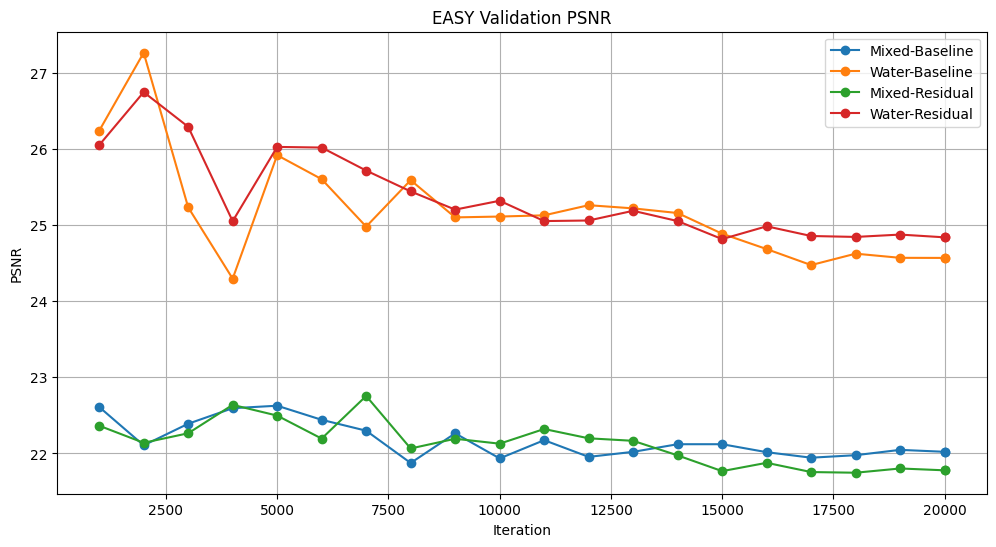

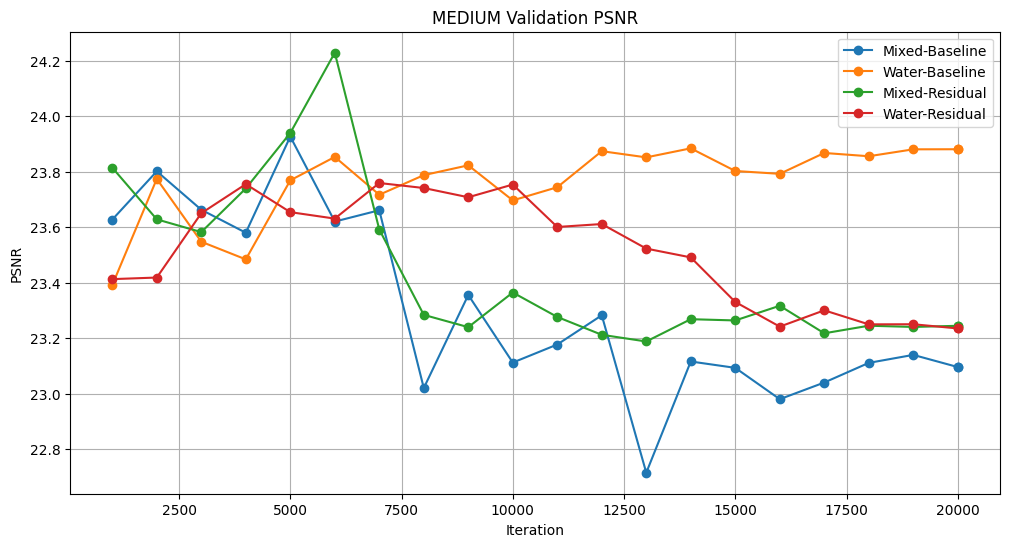

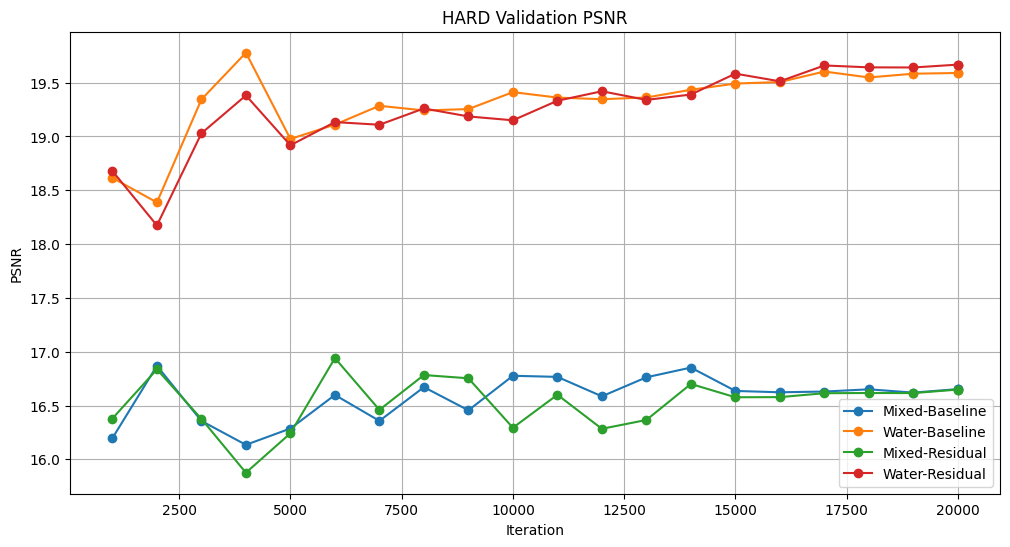

### 그래프 해석하기 Train부분 - Baseline

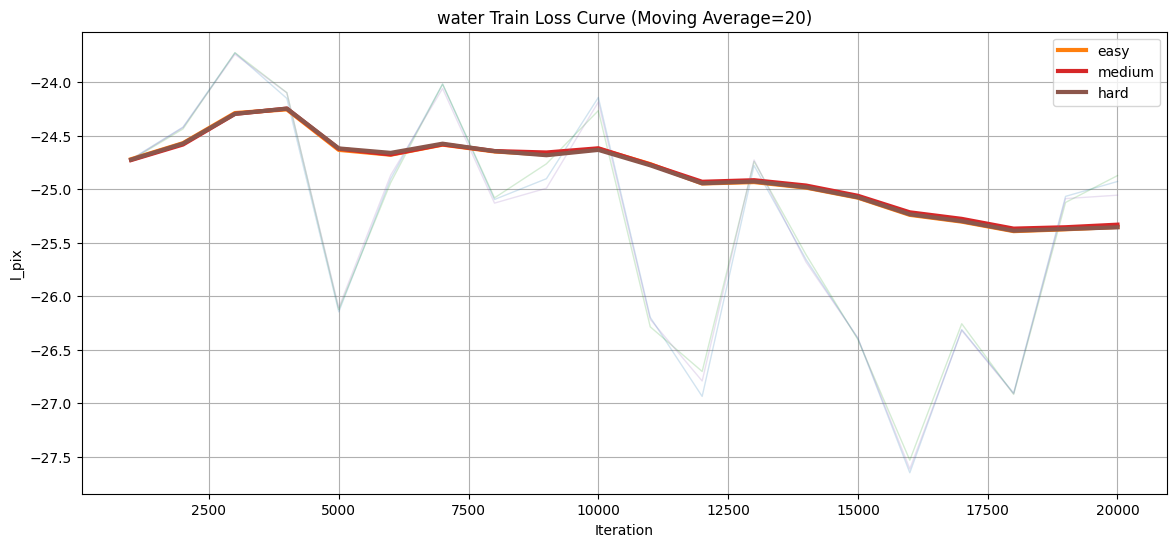

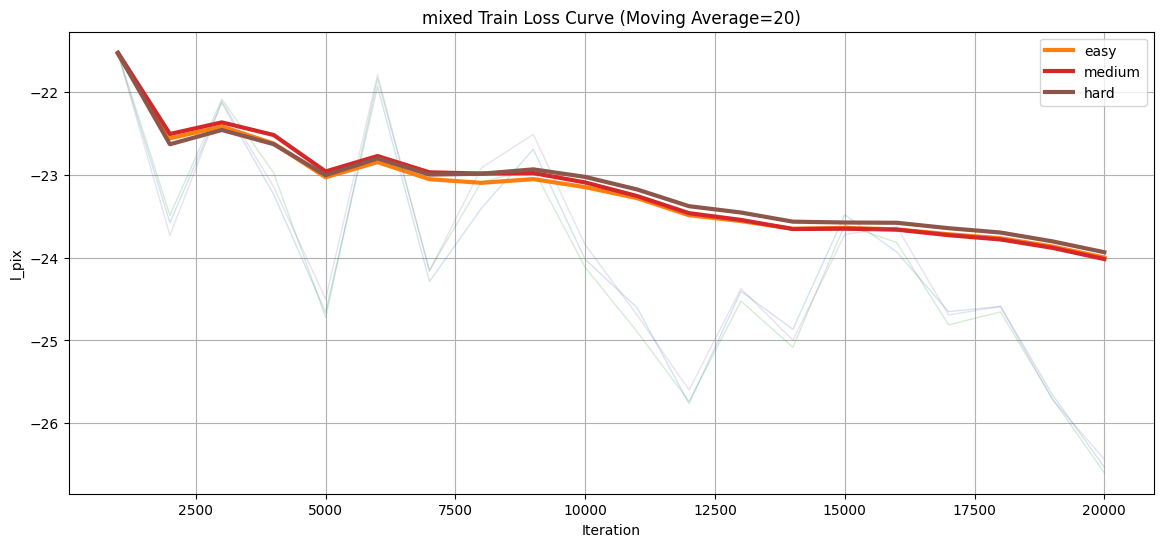

### 그래프 해석하기 Train부분 - Residual실험시

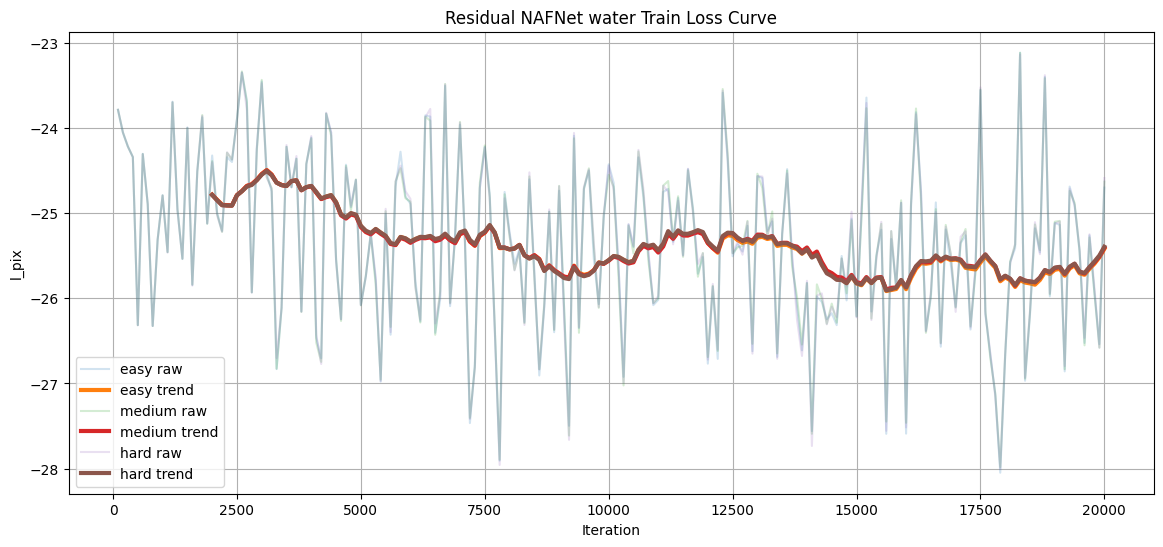

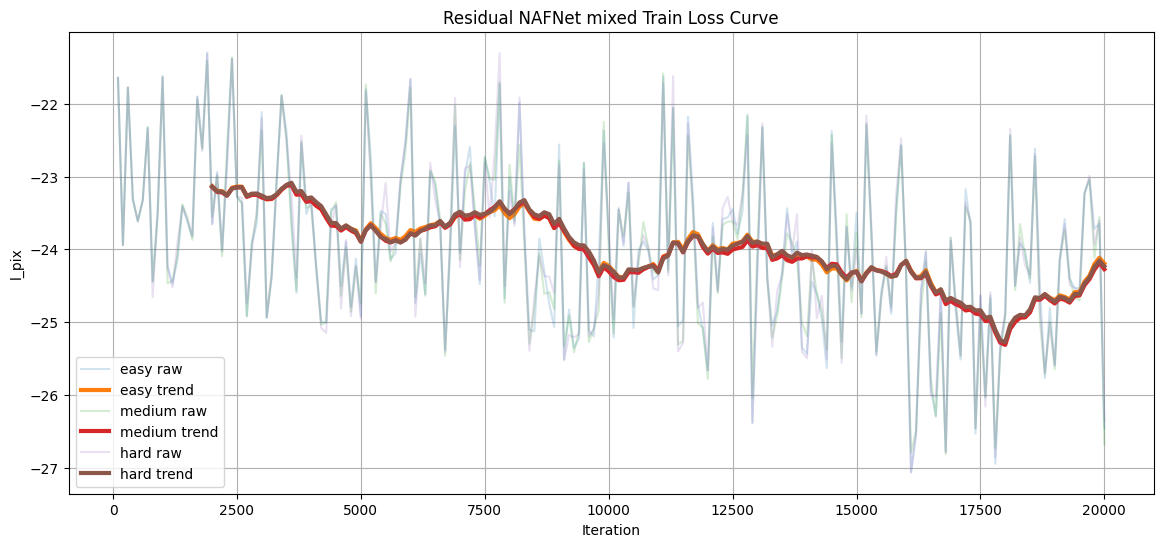

Baseline NAFNet은 네트워크 내부의 다중 Skip Connection과 최종 Global Residual Connection을 통해 입력 이미지에 대한 점진적인 보정을 수행한다. 반면, 제안한 Residual Prediction 방식은 오염 성분 전체를 직접 예측하도록 학습되므로 최적화 난이도가 증가할 수 있다. 실제로 학습 과정에서 Validation 성능 변동성이 상대적으로 크게 나타나는 경향을 확인하였다.